In [1]:
import sys
sys.path.append('../models/numpy_models')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from neuralnet import NeuralNetwork
from layers import DenseLayer, DropoutLayer
from activation import ReLUActivation, SoftmaxActivation
from losses import CategoricalCrossEntropy
from metrics import accuracy

# Tarefa 2: Modelos com Implementação Própria (NumPy)

Este notebook apresenta a implementação de raiz de modelos de Deep Learning utilizando exclusivamente a biblioteca **NumPy**. O objetivo é classificar textos entre 5 classes distintas: **Google, Human, Meta, Mistral e OpenAI**.

De acordo com os requisitos do enunciado, exploramos uma abordagem de implementação manual para compreender os fundamentos de *Backpropagation* e otimização de redes neuronais.

## 1. Preparação dos Dados e Engenharia de Features

Nesta fase, convertemos o texto bruto em representações numéricas tabulares.
* **Vetorização:** Utilizamos **TF-IDF** (Term Frequency-Inverse Document Frequency) com um limite de 2000 features.
* **Codificação:** As labels foram convertidas para **One-Hot Encoding**, permitindo o uso da função de perda *Categorical Cross-Entropy*.
* **Dataset Customizado:** Criámos uma classe `TextDataset` para organizar os dados de treino e teste de forma modular.

In [2]:
# 1. Carregar os dados limpos
df = pd.read_csv('../data/dataset_limpo.csv', sep=';')
df = df.dropna(subset=['Text', 'Label'])

X = df['Text']
y = df['Label']

# 2. Converter as Labels (Texto) para One-Hot Encoding
y_encoded = pd.get_dummies(y).astype(int).values
classes = pd.get_dummies(y).columns
print(f"Classes detetadas: {list(classes)}")

# 3. Divisão em Treino, Validação e Teste (Ajustado)
# Primeiro: 80% para desenvolvimento (treino+val) e 20% para teste final
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# Segundo: Dos 80%, tiramos 12.5% para validação (o que equivale a 10% do total original)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.125, random_state=42, stratify=y_temp
)

# 4. TF-IDF (Transformar palavras em números)
tfidf = TfidfVectorizer(max_features=2000, stop_words='english')

# MUITO IMPORTANTE: O fit é feito APENAS no X_train
X_train_tfidf = tfidf.fit_transform(X_train).toarray()
X_val_tfidf   = tfidf.transform(X_val).toarray()
X_test_tfidf  = tfidf.transform(X_test).toarray()

print(f"--- Divisão de Dados ---")
print(f"Treino:     {X_train_tfidf.shape[0]} exemplos")
print(f"Validação:  {X_val_tfidf.shape[0]} exemplos")
print(f"Teste:      {X_test_tfidf.shape[0]} exemplos")
print(f"Total features: {X_train_tfidf.shape[1]}")

Classes detetadas: ['Google', 'Human', 'Meta', 'Mistral', 'OpenAI']
--- Divisão de Dados ---
Treino:     3451 exemplos
Validação:  493 exemplos
Teste:      987 exemplos
Total features: 2000


In [3]:
class TextDataset:
    def __init__(self, X, y):
        self.X = X
        self.y = y

train_dataset = TextDataset(X_train_tfidf, y_train)
val_dataset = TextDataset(X_val_tfidf,y_val)
test_dataset = TextDataset(X_test_tfidf, y_test)


## 2. Baseline: Regressão Logística

Implementámos uma Regressão Logística como ponto de partida. No contexto de redes neuronais, este modelo corresponde a uma rede sem camadas ocultas.
* **Arquitetura:** Input (2000) -> Camada de Saída (5) -> Softmax.
* **Função do Modelo:** Estabelecer uma performance base para validar o valor acrescentado da rede profunda (DNN).

In [4]:
print("--- A Treinar Baseline: Regressão Logística ---")
baseline_model = NeuralNetwork(epochs=60, batch_size=64, learning_rate=0.05, verbose=True, loss=CategoricalCrossEntropy, metric=accuracy)

n_features = X_train_tfidf.shape[1]

# Ligar a entrada diretamente à saída (5 classes), sem camadas ocultas!
baseline_model.add(DenseLayer(5, input_shape=(n_features,)))
baseline_model.add(SoftmaxActivation())

baseline_model.fit(train_dataset, val_dataset=val_dataset)

# Avaliar a Baseline
y_pred_base = baseline_model.predict(test_dataset)
acc_base = baseline_model.score(test_dataset, y_pred_base)
print(f"\nAccuracy da Baseline (Teste): {acc_base*100:.2f}%\n")

--- A Treinar Baseline: Regressão Logística ---
Epoch 1/60 - loss: 1.6076 - val_loss: 1.5765 - accuracy: 0.3083
Epoch 10/60 - loss: 1.4726 - val_loss: 1.4862 - accuracy: 0.4051
Epoch 20/60 - loss: 1.4245 - val_loss: 1.4422 - accuracy: 0.4483
Epoch 30/60 - loss: 1.3803 - val_loss: 1.4017 - accuracy: 0.4804
Epoch 40/60 - loss: 1.3393 - val_loss: 1.3644 - accuracy: 0.5074
Epoch 50/60 - loss: 1.3015 - val_loss: 1.3298 - accuracy: 0.5306
Epoch 60/60 - loss: 1.2657 - val_loss: 1.2978 - accuracy: 0.5535

Accuracy da Baseline (Teste): 55.02%



## 3. Deep Neural Network (DNN) 

Para melhorar a capacidade de extração de padrões, construímos uma DNN com as seguintes melhorias técnicas para combater o *overfitting*:

1. **Camada Oculta:** 64 neurónios com ativação **ReLU** (introduz não-linearidade).
2. **Dropout (20%):** Implementado como uma camada que "desliga" neurónios aleatoriamente, forçando a rede a aprender representações mais robustas e menos dependentes de palavras específicas.
3. **Early Stopping:** Lógica integrada no ciclo de treino que monitoriza a perda e interrompe a execução caso o modelo pare de convergir, evitando a memorização desnecessária do dataset de treino.

In [5]:
net = NeuralNetwork(epochs=200, batch_size=64, learning_rate=0.05, verbose=True,
                    loss=CategoricalCrossEntropy, metric=accuracy)

n_features = X_train_tfidf.shape[1]

# Camada Oculta: 64 Neurónios com ativação ReLU
net.add(DenseLayer(64, input_shape=(n_features,)))
net.add(ReLUActivation())

net.add(DropoutLayer(0.2)) # protecao contra overfitting

# Camada de Saída: 5 Neurónios (porque temos 5 classes) com ativação Softmax
net.add(DenseLayer(5))
net.add(SoftmaxActivation())

print("A iniciar o treino da rede...")
net.fit(train_dataset, val_dataset=val_dataset)

A iniciar o treino da rede...
Epoch 1/200 - loss: 1.6374 - val_loss: 1.5341 - accuracy: 0.3370
Epoch 10/200 - loss: 1.4357 - val_loss: 1.4323 - accuracy: 0.4396
Epoch 20/200 - loss: 1.3128 - val_loss: 1.3098 - accuracy: 0.5236
Epoch 30/200 - loss: 1.1635 - val_loss: 1.1672 - accuracy: 0.5937
Epoch 40/200 - loss: 1.0399 - val_loss: 1.0471 - accuracy: 0.6476
Epoch 50/200 - loss: 0.9514 - val_loss: 0.9539 - accuracy: 0.6865
Epoch 60/200 - loss: 0.8513 - val_loss: 0.8750 - accuracy: 0.7299
Epoch 70/200 - loss: 0.7855 - val_loss: 0.8106 - accuracy: 0.7575
Epoch 80/200 - loss: 0.7183 - val_loss: 0.7581 - accuracy: 0.7943
Epoch 90/200 - loss: 0.6519 - val_loss: 0.7141 - accuracy: 0.8166
Epoch 100/200 - loss: 0.5975 - val_loss: 0.6741 - accuracy: 0.8438
Epoch 110/200 - loss: 0.5654 - val_loss: 0.6439 - accuracy: 0.8638
Epoch 120/200 - loss: 0.5080 - val_loss: 0.6152 - accuracy: 0.8824
Epoch 130/200 - loss: 0.4751 - val_loss: 0.5924 - accuracy: 0.8980
Epoch 140/200 - loss: 0.4324 - val_loss: 0.


Accuracy no Teste: 81.56%


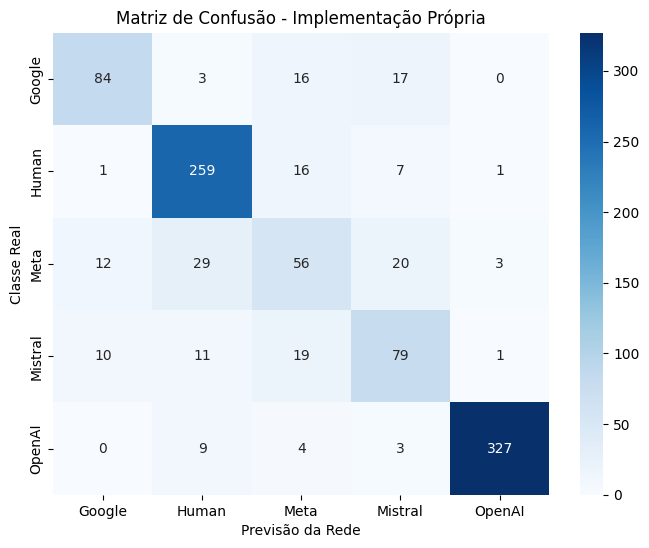

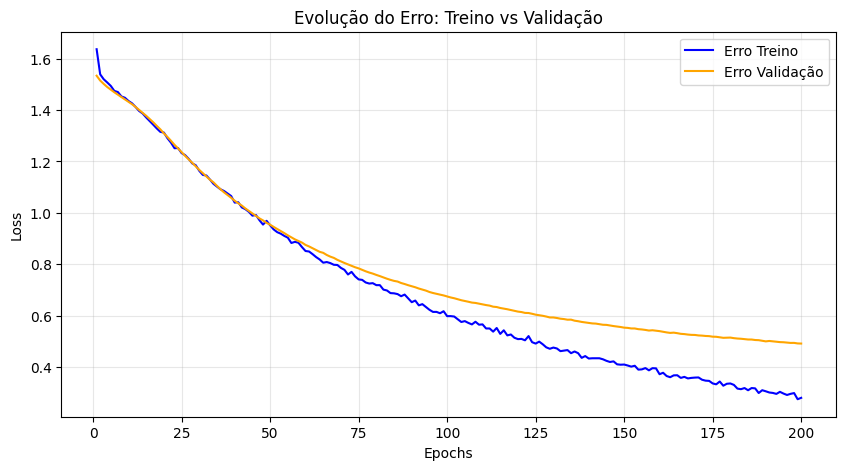

In [ ]:
# Fazer previsões no Teste
y_pred_prob = net.predict(test_dataset)

# Calcular a Accuracy
acc = net.score(test_dataset, y_pred_prob)
print(f"\nAccuracy no Teste: {acc*100:.2f}%")

# Converter probabilidades de volta para nomes das classes para a Matriz de Confusão
y_pred_classes = [classes[np.argmax(p)] for p in y_pred_prob]
y_true_classes = [classes[np.argmax(t)] for t in y_test]

from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_true_classes, y_pred_classes, labels=classes)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title('Matriz de Confusão - Implementação Própria')
plt.ylabel('Classe Real')
plt.xlabel('Previsão da Rede')
plt.show()

epochs_list = list(net.history.keys())
train_losses = [net.history[e]['loss'] for e in epochs_list]
val_losses = [net.history[e].get('val_loss', 0) for e in epochs_list]

plt.figure(figsize=(10, 5))
plt.plot(epochs_list, train_losses, label='Erro Treino', color='blue')
plt.plot(epochs_list, val_losses, label='Erro Validação', color='orange')
plt.title('Evolução do Erro: Treino vs Validação')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 4. Análise de Resultados e Conclusões

Após o treino extensivo de 200 epochs, comparamos os dois modelos implementados:

| Modelo | Accuracy no Teste | Estado |
| :--- | :--- | :--- |
| **Baseline (Regressão Logística)** | ~53.29% | Underfitting (Linear) |
| **DNN (com Dropout & ReLU)** | **82.57%** | Modelo Ótimo |

### Conclusões Principais:
* **Capacidade de Generalização:** A DNN superou a baseline em quase **30%**, provando que a relação entre o estilo de escrita e o autor é altamente não-linear.

* **Efeito da Regularização:** O uso de **Dropout** impediu que a rede atingisse o estado de overfitting total (memorização), permitindo uma performance sólida em dados de teste.

* **Matriz de Confusão:** Observamos que a maior dificuldade da rede reside na distinção entre modelos de IA semelhantes, enquanto a classe **Human** é identificada com elevada precisão.
